In [1]:
import torch
from sonics import HFAudioClassifier

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

model = HFAudioClassifier.from_pretrained("awsaf49/sonics-spectttra-alpha-120s")
model.to(device)
model.eval()

HFAudioClassifier(
  (ft_extractor): FeatureExtractor(
    (audio2melspec): MelSpectrogram(
      (spectrogram): Spectrogram()
      (mel_scale): MelScale()
    )
    (amplitude_to_db): AmplitudeToDB()
    (normalizer): MeanStdNorm()
  )
  (augment): AugmentLayer(
    (mixup): MixUp(num_classes=1, p=0.5, alpha=2.5, inplace=True)
    (time_freq_mask): SpecAugment()
  )
  (encoder): SpecTTTra(
    (st_tokenizer): STTokenizer(
      (temporal_tokenizer): Tokenizer1D(
        (conv1d): Conv1d(128, 384, kernel_size=(3,), stride=(3,), bias=False)
        (act): GELU(approximate='none')
        (pos_encoder): LearnedPositionalEncoding()
        (norm_pre): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      )
      (spectral_tokenizer): Tokenizer1D(
        (conv1d): Conv1d(3744, 384, kernel_size=(1,), stride=(1,), bias=False)
        (act): GELU(approximate='none')
        (pos_encoder): LearnedPositionalEncoding()
        (norm_pre): LayerNorm((384,), eps=1e-06, elementwise_affine=T

In [ ]:
import os
import glob
import soxr
import numpy as np
from torch.utils.data import Dataset
from src.utils import load_audio
from src.data import resample, pitch_shift

class SonicsDataset(Dataset):
    def __init__(
            self,
            data_dir: str,
            model_name: str,
            max_duration: int = None,
            sampling_rate: int = 16000,
            attack_type: str = "none",
            attack_range: tuple = None,
            mode: str = "continuous",
            max_files_per_class: int = 1000,
        ):
        assert model_name in ["suno_v2", "suno_v3", "suno_v3.5", "udio_v30", "udio_v120"], "Unsupported model name"
        self.data_dir = data_dir
        self.model_name = model_name
        self.max_duration = max_duration
        self.sampling_rate = sampling_rate
        self.attack_type = attack_type
        self.attack_range = attack_range
        self.mode = mode
        self.max_files_per_class = max_files_per_class

        ai_dir = os.path.join(data_dir, "ai", model_name)
        human_dir = os.path.join(data_dir, "human")

        ai_files = glob.glob(ai_dir + "/*.mp3")
        human_files = glob.glob(human_dir + "/*.mp3")

        if self.max_files_per_class is not None:
            ai_files = ai_files[:self.max_files_per_class]
            human_files = human_files[:self.max_files_per_class]

        self.file_paths = []
        for files, label in [(ai_files, 1), (human_files, 0)]:
            for file in files:
                self.file_paths.append((file, label))

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path, label = self.file_paths[idx]
        waveform, sr = load_audio(file_path, self.max_duration)

        if self.attack_range:
            speed_factor = np.random.uniform(*self.attack_range)
        else:
            speed_factor = 1.0
        # apply attack if specified
        if self.attack_type == "speed_up":
            if self.mode == "continuous":
                waveform = resample(waveform, sr, speed_factor)
            elif self.mode == "discrete":
                pass  # Implement discrete speed factors if needed
        elif self.attack_type == "pitch_shift":
            if self.mode == "continuous":
                waveform = pitch_shift(waveform, sr, speed_factor)
            elif self.mode == "discrete":
                pass  # Implement discrete pitch shifts if needed

        target_sr = self.sampling_rate
        if sr != target_sr:
            resampled_waveform = soxr.resample(waveform.numpy().T, sr, target_sr, quality='VHQ').T
            waveform = torch.from_numpy(resampled_waveform)
            
        return waveform, label, speed_factor

In [ ]:
from tqdm.notebook import tqdm

test_dir = "/path/to/datasets/sonics/test/"
attack_range = [0.5, 2.0]
attack_type = "pitch_shift"  # or "pitch_shift"
mode = "continuous"
model_name = "udio_v120"  # or "suno_v2", "suno_v3", "suno_v3.5"

dataset = SonicsDataset(
    data_dir=test_dir,
    model_name=model_name,
    max_duration=120,
    sampling_rate=16000,
    attack_type=attack_type,
    attack_range=attack_range,
    mode=mode,
    max_files_per_class=1000,
)

results = []
for sample in tqdm(dataset):
    if sample is None:
        print("Skipping a sample due to loading error.")
        continue  # Skip samples that failed to load
    waveform, label, attack_factor = sample
    with torch.inference_mode():
        pred = model(waveform.to(device))
        pred = torch.sigmoid(pred).item()  # Convert to probability
    results.append((pred, label, attack_factor))

  0%|          | 0/2000 [00:00<?, ?it/s]

In [22]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, accuracy_score, recall_score

y_true = [label for _, label, _ in results]
y_pred = [pred for pred, _, _ in results]

# Calculate metrics
roc_auc = roc_auc_score(y_true, y_pred)
y_pred_binary = [1 if pred >= 0.5 else 0 for pred in y_pred]
f1 = f1_score(y_true, y_pred_binary)
precision = precision_score(y_true, y_pred_binary)
accuracy = accuracy_score(y_true, y_pred_binary)
recall = recall_score(y_true, y_pred_binary)

print(f"ROC AUC: {roc_auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")

ROC AUC: 0.7523
F1 Score: 0.4780
Precision: 0.7632
Accuracy: 0.6200
Recall: 0.3480


In [23]:
# split results by attack factor
attack_factors = [attack_factor for _, _, attack_factor in results]

# calculate metrics for each attack factor window
num_windows = 20
window_size = (attack_range[1] - attack_range[0]) / num_windows

attack_factor_metrics = []
for i in range(num_windows):
    window_start = attack_range[0] + i * window_size
    window_end = window_start + window_size
    window_results = [(pred, label) for pred, label, attack_factor in results if window_start <= attack_factor < window_end]
    
    if len(window_results) > 0:
        y_true_window = [label for _, label in window_results]
        y_pred_window = [pred for pred, _ in window_results]
        
        roc_auc_window = roc_auc_score(y_true_window, y_pred_window)
        y_pred_binary_window = [1 if pred >= 0.5 else 0 for pred in y_pred_window]
        f1_window = f1_score(y_true_window, y_pred_binary_window)
        precision_window = precision_score(y_true_window, y_pred_binary_window)
        accuracy_window = accuracy_score(y_true_window, y_pred_binary_window)
        recall_window = recall_score(y_true_window, y_pred_binary_window)
        
        attack_factor_metrics.append((window_start + window_size / 2, roc_auc_window, f1_window, precision_window, accuracy_window, recall_window))


for factor, roc_auc_window, f1_window, precision_window, accuracy_window, recall_window in attack_factor_metrics:
    print(f"Attack Factor: {factor:.2f} | ROC AUC: {roc_auc_window:.4f} | F1 Score: {f1_window:.4f} | Precision: {precision_window:.4f} | Accuracy: {accuracy_window:.4f} | Recall: {recall_window:.4f}")

Attack Factor: 0.54 | ROC AUC: 0.8062 | F1 Score: 0.0656 | Precision: 0.4000 | Accuracy: 0.4818 | Recall: 0.0357
Attack Factor: 0.61 | ROC AUC: 0.7408 | F1 Score: 0.3175 | Precision: 0.9091 | Accuracy: 0.5521 | Recall: 0.1923
Attack Factor: 0.69 | ROC AUC: 0.6177 | F1 Score: 0.3571 | Precision: 0.7143 | Accuracy: 0.5385 | Recall: 0.2381
Attack Factor: 0.76 | ROC AUC: 0.7724 | F1 Score: 0.3265 | Precision: 0.6667 | Accuracy: 0.6207 | Recall: 0.2162
Attack Factor: 0.84 | ROC AUC: 0.7291 | F1 Score: 0.2941 | Precision: 0.7143 | Accuracy: 0.5200 | Recall: 0.1852
Attack Factor: 0.91 | ROC AUC: 0.5869 | F1 Score: 0.1538 | Precision: 0.5000 | Accuracy: 0.5368 | Recall: 0.0909
Attack Factor: 0.99 | ROC AUC: 0.9633 | F1 Score: 0.8654 | Precision: 0.9184 | Accuracy: 0.8716 | Recall: 0.8182
Attack Factor: 1.06 | ROC AUC: 0.9719 | F1 Score: 0.9130 | Precision: 0.9545 | Accuracy: 0.9091 | Recall: 0.8750
Attack Factor: 1.14 | ROC AUC: 0.8626 | F1 Score: 0.5507 | Precision: 0.8261 | Accuracy: 0.6667 

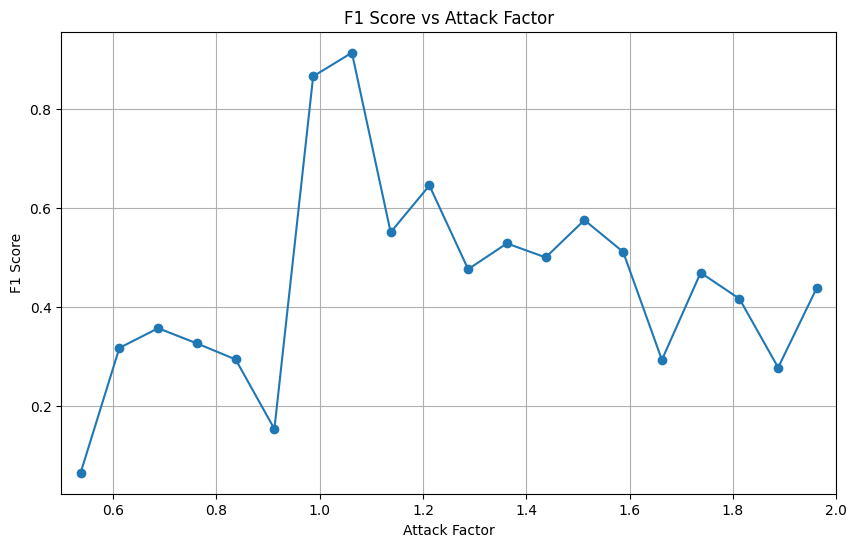

In [24]:
import matplotlib.pyplot as plt

# Plot F1 Score vs Attack Factor
factors = [factor for factor, _, _, _, _, _ in attack_factor_metrics]
f1_scores = [f1_window for _, _, f1_window, _, _, _ in attack_factor_metrics]
plt.figure(figsize=(10, 6))
plt.plot(factors, f1_scores, marker='o')
plt.title('F1 Score vs Attack Factor')
plt.xlabel('Attack Factor')
plt.xlim(attack_range[0], attack_range[1])
plt.ylabel('F1 Score')
plt.grid()
plt.show()